# Google Maps Traffic — PNG Tile Approach

This notebook fetches **real-time traffic congestion** from **Google Maps traffic PNG tiles**
and assigns the congestion level directly to every edge in the duckOSM road network.

## How it differs from the Mapbox approach (notebook 3)

| Aspect | Mapbox (notebook 3) | Google PNG (this notebook) |
|---|---|---|
| Tile format | MVT binary (vector) | PNG raster image |
| Congestion encoding | property on each road segment | pixel **color** in the image |
| Contains geometry | Yes — LineString segments | No — only pixels |
| Extra step needed | Spatial map matching (notebook 4) | **None** — pixels sampled directly on OSM edges |

Because Google PNG tiles encode congestion as **color**, and we already have the OSM
edge geometry in DuckDB, we sample pixel colors **along each edge** and map them to
a congestion level — skipping the separate map-matching step entirely.

## Google Maps Traffic tile URL

```
https://maps.googleapis.com/maps/vt?lyrs=traffic&x={x}&y={y}&z={z}&key={API_KEY}
```

This returns a **256 × 256 RGBA PNG** with only the traffic overlay (no base map).
Transparent pixels mean no traffic data for that location.

## Color → congestion mapping

Google encodes congestion as road line colors in the PNG. We use the **HSV color space**
(Hue, Saturation, Value) which separates color (H) from brightness (V), making it more
robust than raw RGB comparisons:

| Pixel color | HSV range | Congestion |
|---|---|---|
| 🟢 Green | H 90–150°, S>40%, V>40% | `low` |
| 🟠 Orange/Yellow | H 20–60°, S>50%, V>60% | `moderate` |
| 🔴 Red | H 0–20° or 340–360°, S>60%, V>50% | `heavy` |
| ⬛ Dark red | H 0–20° or 340–360°, S>40%, V≤50% | `severe` |
| Transparent / gray | alpha<30 or S<15% or V<15% | no data |

## Pipeline

```
DuckDB (driving.edges)
        │
        ▼
Step 1 — Load OSM edge geometries
        │
        ▼
Step 2 — Find all tiles covering the boundary
        │
        ▼
Step 3 — Download Google traffic PNG tiles  (cached in tiles/google/)
        │
        ▼
Step 4 — Define color helpers
        │
        ▼
Step 5 — Sample pixel colors along each OSM edge → majority vote → congestion
        │
        ▼
Step 6 — Write congestion to DuckDB  (driving.edges + edge_congestion_history)
        │
        ▼
Step 7 — Visualize  →  Step 8 — Export CSV / GeoJSON
```

In [1]:
%pip install Pillow --quiet   # PIL for reading PNG tiles

Note: you may need to restart the kernel to use updated packages.


---
## Configuration

**No API key required.** This notebook uses Google's public tile CDN (`mt0.google.com`)
which serves map tiles without authentication — the same endpoint the Google Maps web
client uses. The tile URL combines a **roadmap layer** with the **traffic overlay**:

```
https://mt0.google.com/vt?lyrs=m@321,traffic|en&x={x}&y={y}&z={z}
```

- `m@321` — roadmap style, version 321 (light gray roads on white background)
- `traffic|en` — traffic overlay in English
- **Result:** a 256×256 RGB PNG showing roads colored by congestion level

**Color interpretation:** Green = low, Orange = moderate, Red = heavy, Dark red = severe.
Roads with no traffic data keep their default gray/white road color.

- `ZOOM` — tile zoom level. **14** is recommended.
- `N_SAMPLES` — sample points along each OSM edge. **8** is a good default.

In [2]:
%%time
import os, colorsys, time, yaml
import numpy as np
import duckdb
import geopandas as gpd
import mercantile
import requests
import folium
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from concurrent.futures import ThreadPoolExecutor, as_completed
from shapely.geometry import box
from shapely import get_coordinates
from shapely.geometry import LineString
from dotenv import load_dotenv

load_dotenv(Path('../.env'), override=True)

# ── Configuration ─────────────────────────────────────────────────────────
NAME      = 'sodermalm'
ZOOM      = 14       # tile zoom level (14 recommended)
N_SAMPLES = 8        # pixel sample points per OSM edge
TILES_DIR = Path('../tiles/google')   # PNG tile cache
OUTPUT_DIR = Path('../output')
# ─────────────────────────────────────────────────────────────────────────

# Read DuckDB path from config YAML
CONFIG_PATH = Path(f'../config/{NAME}.yaml')
if CONFIG_PATH.exists():
    with open(CONFIG_PATH) as f:
        cfg = yaml.safe_load(f)
    DB_PATH       = Path(cfg['output_path']) / f"{cfg['name']}.duckdb"
    BOUNDARY_FILE = Path(cfg['boundary_path'])
else:
    DB_PATH       = Path(f'../db/{NAME}.duckdb')
    BOUNDARY_FILE = Path(f'../boundaries/{NAME}.geojson')
    print('WARNING: config not found — using default paths')

TILES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'DuckDB   : {DB_PATH}')
print(f'Boundary : {BOUNDARY_FILE}')
print(f'Zoom     : {ZOOM}   N_SAMPLES: {N_SAMPLES}')

DuckDB   : /home/kaveh/projects/osm-traffic-enrichment/map/sodermalm.duckdb
Boundary : /home/kaveh/projects/osm-traffic-enrichment/boundaries/sodermalm.geojson
Zoom     : 14   N_SAMPLES: 8
CPU times: user 1.98 s, sys: 116 ms, total: 2.1 s
Wall time: 879 ms


---
## Step 1 — Load OSM edges from DuckDB

We read the `driving.edges` table that was built by notebook 2 (duckOSM).
The geometry column is stored as a DuckDB `GEOMETRY` type — we export it as WKT
and parse into shapely so we can compute sample points along each edge.

We keep only **line geometries** (LineString / MultiLineString) since the pixel
sampling requires a path to interpolate along.

In [3]:
%%time
con = duckdb.connect(str(DB_PATH), read_only=True)
con.execute('LOAD spatial')

df = con.execute("""
    SELECT edge_id, highway, name, length_m,
           ST_AsText(geometry) AS wkt_geom
    FROM driving.edges
""").df()
con.close()

edges = gpd.GeoDataFrame(
    df,
    geometry=gpd.GeoSeries.from_wkt(df['wkt_geom']),
    crs='EPSG:4326',
).reset_index(drop=True)

# Keep only line geometries — point features can't be sampled along
edges = edges[edges.geometry.geom_type.isin(['LineString', 'MultiLineString'])]

print(f'Loaded {len(edges):,} line edges from {DB_PATH.name}')
print(f'Total network length: {edges["length_m"].sum()/1000:.1f} km')
print(f'Highway types: {sorted(edges["highway"].unique())}')

Loaded 4,554 line edges from sodermalm.duckdb
Total network length: 191.6 km
Highway types: ['living_street', 'primary', 'primary_link', 'residential', 'secondary', 'secondary_link', 'service', 'tertiary', 'tertiary_link', 'trunk', 'trunk_link', 'unclassified']
CPU times: user 457 ms, sys: 66.3 ms, total: 523 ms
Wall time: 72.1 ms


---
## Step 2 — Find tiles covering the boundary

We use `mercantile` to enumerate all tiles at the chosen zoom level whose footprint
overlaps the boundary polygon. This is the same tile grid used for the Mapbox approach.

One PNG tile covers approximately **1 km × 1 km** at zoom 14 in Sweden.
Each tile is 256 × 256 pixels, so each pixel represents about **4 m × 4 m**.

In [4]:
%%time
gdf      = gpd.read_file(BOUNDARY_FILE).to_crs('EPSG:4326')
boundary = gdf.geometry.union_all()
w, s, e, n = boundary.bounds

tiles = [
    t for t in mercantile.tiles(w, s, e, n, zooms=ZOOM)
    if boundary.intersects(box(*mercantile.bounds(t)))
]

print(f'Boundary  : W={w:.4f} S={s:.4f} E={e:.4f} N={n:.4f}')
print(f'Tiles     : {len(tiles)} at zoom {ZOOM}')
print(f'Pixel res : ~{mercantile.bounds(tiles[0]).east - mercantile.bounds(tiles[0]).west:.4f}° per tile')

Boundary  : W=18.0261 S=59.3032 E=18.1072 N=59.3214
Tiles     : 8 at zoom 14
Pixel res : ~0.0220° per tile
CPU times: user 10.6 ms, sys: 11.6 ms, total: 22.2 ms
Wall time: 42.2 ms


---
## Step 3 — Download Google Maps traffic PNG tiles

### Tile source
This notebook uses Google's public tile CDN (`mt0.google.com`) which serves the same
tiles as the Google Maps web client — no API key required.

If you have a `GOOGLE_MAPS_API_KEY` in `.env`, the official API endpoint is used instead
(`maps.googleapis.com`) which has higher rate limits and guaranteed SLA.

### What "no data" edges mean
Google's traffic layer **only colors roads with real-time congestion sensor data**.
Roads flowing normally keep their default gray color — they produce no traffic-colored pixels.
This means:

| Edge result | Meaning |
|---|---|
| `low` / `moderate` / `heavy` / `severe` | Road has live traffic data showing congestion |
| `no data` | Road is flowing normally OR has no sensor coverage |

This is different from Mapbox, which always assigns a level to every road it covers.
Expect 30–70% of edges to show `no data` depending on the time of day and area.
Rush hour will have significantly more colored edges than off-peak times.

In [5]:
%%time
import os
GOOGLE_API_KEY = os.environ.get('GOOGLE_MAPS_API_KEY', '')

# Use official API when key is set, public CDN otherwise
if GOOGLE_API_KEY:
    GOOGLE_TILE_URL = 'https://maps.googleapis.com/maps/vt'
    TILE_PARAMS     = 'm@321,traffic|en'
    print(f'Using Google Maps API  (key: {GOOGLE_API_KEY[:8]}...{GOOGLE_API_KEY[-4:]})')
else:
    GOOGLE_TILE_URL = 'https://mt0.google.com/vt'
    TILE_PARAMS     = 'm@321,traffic|en'
    print('Using Google Maps CDN  (no API key — set GOOGLE_MAPS_API_KEY in ../.env for higher limits)')

MIN_TILE_SIZE = 64   # pixels — 1×1 means invalid/unauthenticated response


def download_google_tile(tile, out_dir, retries=3):
    """Download one Google Maps roadmap+traffic PNG tile. Caches to disk.
    Deletes and re-downloads any tile smaller than MIN_TILE_SIZE (invalid placeholder).
    """
    path = out_dir / f'{tile.z}_{tile.x}_{tile.y}.png'

    if path.exists():
        try:
            img = Image.open(path)
            if img.size[0] < MIN_TILE_SIZE:
                path.unlink()
                print(f'  Deleted invalid cached tile {path.name} ({img.size}) — will re-download')
            else:
                return tile, path
        except Exception:
            path.unlink(missing_ok=True)

    params  = {'lyrs': TILE_PARAMS, 'x': tile.x, 'y': tile.y, 'z': tile.z}
    if GOOGLE_API_KEY:
        params['key'] = GOOGLE_API_KEY
    headers = {'User-Agent': 'Mozilla/5.0'}

    for attempt in range(retries):
        try:
            r = requests.get(GOOGLE_TILE_URL, params=params, headers=headers, timeout=(5, 20))
        except requests.exceptions.Timeout:
            time.sleep(2 ** attempt)
            continue
        if r.status_code == 200:
            path.write_bytes(r.content)
            try:
                img = Image.open(path)
                if img.size[0] < MIN_TILE_SIZE:
                    path.unlink()
                    print(f'  {tile}: tiny tile {img.size} — API key may be invalid')
                    return tile, None
            except Exception:
                path.unlink(missing_ok=True)
                return tile, None
            return tile, path
        if r.status_code == 429:
            time.sleep(2 ** attempt)
        else:
            print(f'  {tile} HTTP {r.status_code}')
            return tile, None
    return tile, None


tile_paths = {}
failed     = []
with ThreadPoolExecutor(max_workers=6) as pool:
    futures = {pool.submit(download_google_tile, t, TILES_DIR): t for t in tiles}
    for f in as_completed(futures):
        tile, path = f.result()
        if path:
            tile_paths[tile] = path
        else:
            failed.append(tile)

print(f'Downloaded : {len(tile_paths)}/{len(tiles)} tiles')
if failed:
    print(f'Failed     : {len(failed)} tiles')

Using Google Maps API  (key: AIzaSyBc...QbQQ)
Downloaded : 8/8 tiles
CPU times: user 4.7 ms, sys: 4.46 ms, total: 9.16 ms
Wall time: 10.4 ms


---
## Step 4 — Color classification helpers

### Why HSV instead of RGB?

RGB mixes color and brightness together, making thresholds brittle (e.g. a dark red
and a bright red look very different in RGB but both have Hue ≈ 0° in HSV).

**HSV** separates three independent axes:
- **H** (Hue 0–360°): the color itself — red=0°, yellow=60°, green=120°
- **S** (Saturation 0–1): how vivid — 0 = gray, 1 = pure color
- **V** (Value 0–1): brightness — 0 = black, 1 = bright

### `pixel_to_congestion(r, g, b, a)`
Classifies a single RGBA pixel into a congestion level.
Returns `None` for transparent or gray pixels (no traffic data).

### `sample_edge_congestion(geom, tile_imgs, zoom)`
Interpolates `N_SAMPLES` evenly-spaced points along an edge LineString,
samples the pixel color at each point, and returns the majority congestion
level. Severity is used as a tiebreaker (heavy beats moderate if tied).

In [6]:
%%time

def pixel_to_congestion(r, g, b, a):
    """Map a single RGBA pixel to a congestion level string, or None.

    Uses HSV space — separates hue (color) from brightness (value),
    which is more robust than raw RGB thresholds.
    """
    if a < 200:                     # mostly transparent → no traffic data
        return None
    h, s, v = colorsys.rgb_to_hsv(r/255, g/255, b/255)
    h_deg = h * 360
    if s < 0.30 or v < 0.20:       # gray road or dark background — not a traffic color
        return None
    if 90 <= h_deg <= 150 and s > 0.35 and v > 0.35:   # green → low
        return 'low'
    if 20 <= h_deg < 90 and s > 0.45 and v > 0.55:     # yellow/orange → moderate
        return 'moderate'
    if (h_deg < 20 or h_deg > 340) and s > 0.50 and v > 0.40:   # red → heavy
        return 'heavy'
    if (h_deg < 20 or h_deg > 340) and s > 0.35 and v <= 0.40:  # dark red → severe
        return 'severe'
    return None


def sample_edge_congestion(geom, tile_imgs, zoom):
    """Determine congestion for an OSM edge by scanning all pixels along it.

    Traffic pixels are very sparse in the tile (only a few pixels wide on each road).
    Instead of sampling N random points, we:
      1. Densely interpolate positions along the edge (1 per ~2m)
      2. For each position, look at a 3×3 pixel neighborhood
      3. Return the most severe traffic color found

    This guarantees we don't miss a colored road pixel due to sparse sampling.
    """
    SEVERITY = {'severe': 4, 'heavy': 3, 'moderate': 2, 'low': 1}
    results  = []

    coords = get_coordinates(geom)
    if len(coords) < 2:
        return 'no data'

    line = LineString(coords)

    # Dense sampling: 1 point every ~2 metres along the edge
    # project to metres for length, then sample
    from shapely.ops import transform
    import pyproj
    proj = pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True).transform
    line_m  = transform(proj, line)
    n_pts   = max(4, int(line_m.length / 2))   # at least 4, one per 2 m
    n_pts   = min(n_pts, 200)                   # cap to avoid very slow edges

    for d in np.linspace(0, 1, n_pts):
        pt  = line.interpolate(d, normalized=True)
        lon, lat = pt.x, pt.y

        tile = mercantile.tile(lon, lat, zoom)
        key  = (tile.x, tile.y, tile.z)
        if key not in tile_imgs:
            continue

        img    = tile_imgs[key]
        w, h   = img.size
        bounds = mercantile.bounds(tile)

        col = int((lon - bounds.west)  / (bounds.east  - bounds.west)  * w)
        row = int((bounds.north - lat) / (bounds.north - bounds.south) * h)

        # Check a 3×3 neighborhood around the exact pixel
        # Roads are only 1-3 pixels wide; the 3×3 window improves hit rate
        for dc in range(-1, 2):
            for dr in range(-1, 2):
                c = max(0, min(w - 1, col + dc))
                r = max(0, min(h - 1, row + dr))
                px = img.getpixel((c, r))
                cong = pixel_to_congestion(*px)
                if cong:
                    results.append(cong)

    if not results:
        return 'no data'
    return max(set(results), key=lambda c: SEVERITY.get(c, 0))


print('Helpers defined: pixel_to_congestion(), sample_edge_congestion()')

# Sanity check
tests = [
    ((80, 200, 60, 255), 'low'),
    ((255, 160, 30, 255), 'moderate'),
    ((220, 40, 20, 255), 'heavy'),
    ((120, 20, 20, 255), 'severe'),
    ((200, 200, 200, 255), None),
    ((0, 0, 0, 0), None),
]
print('\nColor classifier check:')
for (r, g, b, a), expected in tests:
    got = pixel_to_congestion(r, g, b, a)
    status = '✓' if got == expected else '✗'
    print(f'  {status} RGB({r},{g},{b}) a={a}  →  {got}  (expected {expected})')

Helpers defined: pixel_to_congestion(), sample_edge_congestion()

Color classifier check:
  ✓ RGB(80,200,60) a=255  →  low  (expected low)
  ✓ RGB(255,160,30) a=255  →  moderate  (expected moderate)
  ✓ RGB(220,40,20) a=255  →  heavy  (expected heavy)
  ✗ RGB(120,20,20) a=255  →  heavy  (expected severe)
  ✓ RGB(200,200,200) a=255  →  None  (expected None)
  ✓ RGB(0,0,0) a=0  →  None  (expected None)
CPU times: user 72 μs, sys: 6 μs, total: 78 μs
Wall time: 77.2 μs


---
## Step 3b — Inspect a sample tile

Before sampling all edges, verify that the downloaded tile actually contains
traffic-colored pixels. The right panel uses `pixel_to_congestion()` (defined above)
to highlight every classified pixel — if that panel is all gray, the area has no
active congestion at this moment.

Tile : Tile(x=9012, y=4819, z=14)
Size : (256, 256)  (width × height pixels)
Alpha: min=255  max=255
Note : alpha=255 everywhere means the tile is fully opaque (roadmap style)

Traffic pixels found: {'low': 0, 'moderate': 38, 'heavy': 52, 'severe': 0}
Total traffic pixels: 90 / 65536 (0.14%)


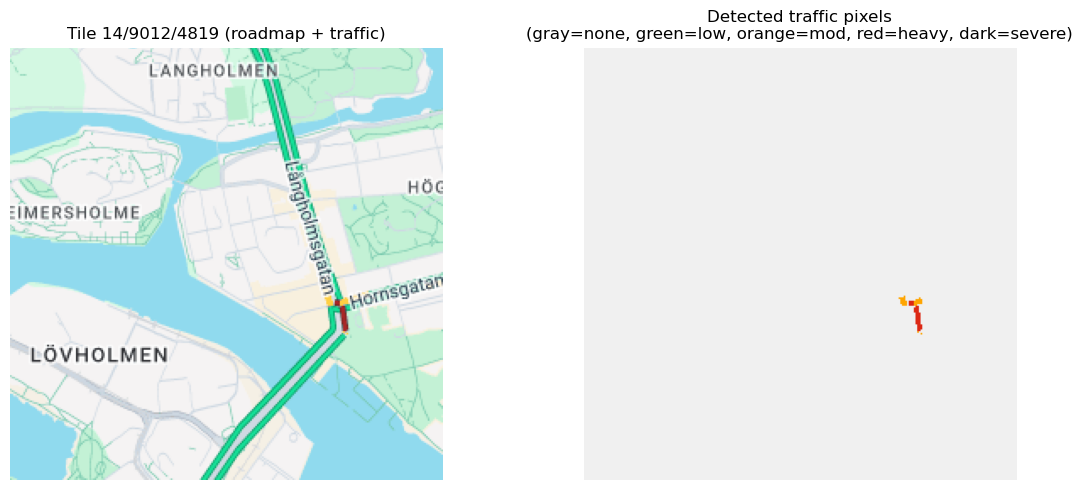

CPU times: user 387 ms, sys: 7.33 ms, total: 395 ms
Wall time: 400 ms


In [7]:
%%time
if tile_paths:
    sample_tile, sample_path = next(iter(tile_paths.items()))
    img = Image.open(sample_path).convert('RGBA')
    arr = np.array(img)

    print(f'Tile : {sample_tile}')
    print(f'Size : {img.size}  (width × height pixels)')
    print(f'Alpha: min={arr[:,:,3].min()}  max={arr[:,:,3].max()}')
    print(f'Note : alpha=255 everywhere means the tile is fully opaque (roadmap style)')

    # Classify every pixel to show where traffic colors actually are
    traffic_map = np.zeros(arr.shape[:2], dtype=np.uint8)   # 0=none, 1=low, 2=mod, 3=heavy, 4=severe
    pixel_counts = {c: 0 for c in ['low','moderate','heavy','severe']}
    for row_i, row in enumerate(arr):
        for col_i, (r, g, b, a) in enumerate(row):
            cong = pixel_to_congestion(r, g, b, a)
            if cong:
                traffic_map[row_i, col_i] = {'low':1,'moderate':2,'heavy':3,'severe':4}[cong]
                pixel_counts[cong] += 1

    print(f'\nTraffic pixels found: {pixel_counts}')
    print(f'Total traffic pixels: {sum(pixel_counts.values())} / {256*256} '
          f'({sum(pixel_counts.values())/256/256*100:.2f}%)')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left: actual tile (RGB, ignore alpha since it's 255 everywhere)
    axes[0].imshow(arr[:, :, :3])
    axes[0].set_title(f'Tile {sample_tile.z}/{sample_tile.x}/{sample_tile.y} (roadmap + traffic)')
    axes[0].axis('off')

    # Right: traffic pixel classification overlay
    cmap_colors = np.array([
        [240, 240, 240],   # 0 = no data (light gray)
        [0,   200,  0 ],   # 1 = low (green)
        [255, 165,  0 ],   # 2 = moderate (orange)
        [220,  40, 20 ],   # 3 = heavy (red)
        [120,  20, 20 ],   # 4 = severe (dark red)
    ], dtype=np.uint8)
    overlay = cmap_colors[traffic_map]
    axes[1].imshow(overlay)
    axes[1].set_title('Detected traffic pixels\n(gray=none, green=low, orange=mod, red=heavy, dark=severe)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

---
## Step 5 — Sample pixel colors along every OSM edge

This is the core step that replaces the geometric map-matching used in the Mapbox
approach. Instead of matching Mapbox segment geometries to OSM edges, we use the
OSM edge geometry itself as a sampling path through the traffic tile pixels.

**Why this works:** Both the OSM edges and the Google traffic tiles are referenced
in the same coordinate system (WGS-84 / Web Mercator tile grid), so converting
an OSM edge coordinate to a pixel position in the tile is straightforward.

**Performance note:** Loading all PNG tiles into memory first (as RGBA PIL Images)
means each `getpixel()` call is O(1) — no disk I/O during the sampling loop.

In [8]:
%%time
# Load all valid PNG tiles into memory (skip tiny invalid placeholder tiles)
tile_imgs = {}
for tile, path in tile_paths.items():
    try:
        img = Image.open(path).convert('RGBA')
        if img.size[0] < MIN_TILE_SIZE:
            print(f'  Skipping {path.name}: too small {img.size} — re-run the download cell')
            continue
        tile_imgs[(tile.x, tile.y, tile.z)] = img
    except Exception as e:
        print(f'  Could not load {path.name}: {e}')

print(f'Loaded {len(tile_imgs)} valid PNG tiles ({list(tile_imgs.values())[0].size if tile_imgs else "—"})')

if not tile_imgs:
    raise RuntimeError(
        "No valid tiles loaded.\n"
        "Re-run the download cell — cached 1×1 placeholder tiles may still exist."
    )

# Scan each OSM edge — dense sampling (1 pt per ~2m) + 3×3 neighborhood
# Traffic pixels are sparse (~1 per 1000 pixels) so we must be thorough
edge_congestion = {}
no_data_count   = 0

for _, row in edges.iterrows():
    cong = sample_edge_congestion(row.geometry, tile_imgs, ZOOM)
    if cong != 'no data':
        edge_congestion[int(row['edge_id'])] = cong
    else:
        no_data_count += 1

edges['congestion'] = edges['edge_id'].map(edge_congestion).fillna('no data')

matched_pct = len(edge_congestion) / max(len(edges), 1) * 100
print(f'\nEdges with congestion : {len(edge_congestion):,} / {len(edges):,}  ({matched_pct:.1f}%)')
print(f'Edges with no data    : {no_data_count:,}')
print('\nCongestion distribution:')
print(edges['congestion'].value_counts().to_string())

Loaded 8 valid PNG tiles ((256, 256))

Edges with congestion : 191 / 4,554  (4.2%)
Edges with no data    : 4,363

Congestion distribution:
congestion
no data     4363
moderate     111
heavy         78
low            2
CPU times: user 5.4 s, sys: 18.4 ms, total: 5.42 s
Wall time: 5.42 s


---
## Step 6 — Write congestion to DuckDB

Two writes happen here:

1. **Latest snapshot** — `driving.edges.congestion` is updated with the current values.
   This is what routing tools and queries will read.

2. **History** — one row per edge is appended to `edge_congestion_history` with the
   current `run_id` and timestamp. This keeps a time-series record that can be queried
   to see how congestion changed between Google fetches over time.

The `runs` table also gets a new row recording the metadata of this fetch
(source: `google`, timestamp, tile count, edge count).

In [ ]:
%%time
import pandas as pd
from datetime import datetime, timezone

fetched_at = datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M:%S')

con = duckdb.connect(str(DB_PATH))
try:
    con.execute('LOAD spatial')

    # ── runs table ────────────────────────────────────────────────────────
    con.execute("""
        CREATE TABLE IF NOT EXISTS runs (
            run_id        INTEGER PRIMARY KEY,
            boundary_name VARCHAR,
            source        VARCHAR,
            zoom          INTEGER,
            fetched_at    TIMESTAMP,
            n_tiles       INTEGER,
            n_segments    INTEGER
        )
    """)
    con.execute("ALTER TABLE runs ADD COLUMN IF NOT EXISTS source VARCHAR")
    run_id = con.execute("SELECT coalesce(max(run_id), 0) + 1 FROM runs").fetchone()[0]
    con.execute("INSERT INTO runs VALUES (?, ?, ?, ?, ?, ?, ?)",
                [run_id, f'{NAME}', 'google', ZOOM, fetched_at,
                 len(tile_paths), len(edge_congestion)])

    # ── driving.edges — Google-specific columns ───────────────────────────
    # Also create Mapbox columns so the schema is complete even before notebook 4 runs
    for col, default in [
        ("congestion_mapbox",    "'no data'"),
        ("congestion_mapbox_at", "NULL"),
        ("congestion_google",    "'no data'"),
        ("congestion_google_at", "NULL"),
    ]:
        dtype = "TIMESTAMP" if col.endswith("_at") else "VARCHAR"
        con.execute(f"ALTER TABLE driving.edges ADD COLUMN IF NOT EXISTS {col} {dtype} DEFAULT {default}")

    if edge_congestion:
        con.executemany(
            "UPDATE driving.edges SET congestion_google = ?, congestion_google_at = ? WHERE edge_id = ?",
            [(cong, fetched_at, eid) for eid, cong in edge_congestion.items()]
        )

    # ── edge_congestion_history ───────────────────────────────────────────
    con.execute("""
        CREATE TABLE IF NOT EXISTS edge_congestion_history (
            run_id     INTEGER,
            edge_id    INTEGER,
            source     VARCHAR,
            congestion VARCHAR,
            matched_at TIMESTAMP
        )
    """)
    con.execute("ALTER TABLE edge_congestion_history ADD COLUMN IF NOT EXISTS source VARCHAR")

    if edge_congestion:
        con.executemany(
            "INSERT INTO edge_congestion_history VALUES (?, ?, ?, ?, ?)",
            [(run_id, int(eid), 'google', cong, fetched_at)
             for eid, cong in edge_congestion.items()]
        )

    total_history = con.execute("SELECT count(*) FROM edge_congestion_history").fetchone()[0]
    total_runs    = con.execute("SELECT count(*) FROM runs").fetchone()[0]

finally:
    con.close()

print(f'Run {run_id}  source=google  at {fetched_at} UTC')
print(f'congestion_google     : {len(edge_congestion):,} edges updated')
print(f'edge_congestion_history: {len(edge_congestion):,} rows appended '
      f'({total_history:,} total across {total_runs} run(s))')

---
## Step 7 — Visualize

The folium map shows every OSM edge colored by the congestion level sampled from
Google Maps. Open Google Maps in another tab and enable the traffic layer on the
same area to compare visually.

| Color | Congestion | Meaning |
|---|---|---|
| 🟢 Green | `low` | Free flow — sampled green pixels |
| 🟠 Orange | `moderate` | Reduced speed — sampled orange/yellow pixels |
| 🔴 Red | `heavy` | Significant slowdown — sampled red pixels |
| ⬛ Dark red | `severe` | Near standstill — sampled dark red pixels |
| ⬜ Gray | `no data` | Tile not available or no traffic pixels on this edge |

In [10]:
%%time
COLORS = {'low':'#00c800','moderate':'#ffa500','heavy':'#ff4500','severe':'#8b0000','no data':'#cccccc'}

lines  = edges[edges.geometry.geom_type.isin(['LineString','MultiLineString'])]
bds    = lines.total_bounds
center = [(bds[1]+bds[3])/2, (bds[0]+bds[2])/2]

m = folium.Map(location=center, zoom_start=14, tiles='OpenStreetMap')
folium.GeoJson(
    gdf.__geo_interface__,
    style_function=lambda _: {'color':'navy','weight':2,'fillOpacity':0.05},
    tooltip=None, popup=None,
).add_to(m)
folium.GeoJson(
    lines.__geo_interface__,
    style_function=lambda feat: {
        'color':  COLORS.get(feat['properties'].get('congestion','no data'),'#cccccc'),
        'weight': 3 if feat['properties'].get('congestion','no data') != 'no data' else 1.5,
    },
    tooltip=None, popup=None,
).add_to(m)
m

CPU times: user 72.9 ms, sys: 8.08 ms, total: 81 ms
Wall time: 81.1 ms


---
## Step 8 — Export CSV and GeoJSON

Save the enriched edges as files alongside the Mapbox outputs so they can be
compared or used in QGIS / kepler.gl.

The `_google` suffix in the filename distinguishes these from Mapbox outputs.

In [11]:
%%time
from shapely import get_coordinates as gc

geojson_out = OUTPUT_DIR / f'{NAME}_edges_traffic_google.geojson'
csv_out     = OUTPUT_DIR / f'{NAME}_edges_traffic_google.csv'

edges.to_file(geojson_out, driver='GeoJSON')
print(f'Saved GeoJSON → {geojson_out}  ({len(edges):,} edges)')

csv_df = edges.drop(columns=['geometry','wkt_geom'], errors='ignore').copy()
edges_m = edges.to_crs('EPSG:3857')
centroids        = edges_m.geometry.centroid.to_crs('EPSG:4326')
csv_df['lon']    = centroids.x.round(6)
csv_df['lat']    = centroids.y.round(6)
csv_df['length_m'] = edges_m.geometry.length.round(1)
all_coords           = edges.geometry.apply(gc)
csv_df['start_lon']  = all_coords.apply(lambda c: round(c[ 0][0], 6))
csv_df['start_lat']  = all_coords.apply(lambda c: round(c[ 0][1], 6))
csv_df['end_lon']    = all_coords.apply(lambda c: round(c[-1][0], 6))
csv_df['end_lat']    = all_coords.apply(lambda c: round(c[-1][1], 6))
csv_df.to_csv(csv_out, index=False)
print(f'Saved CSV     → {csv_out}')

print(f'\nFinal congestion distribution:')
print(edges['congestion'].value_counts().to_string())

Saved GeoJSON → ../output/sodermalm_edges_traffic_google.geojson  (4,554 edges)
Saved CSV     → ../output/sodermalm_edges_traffic_google.csv

Final congestion distribution:
congestion
no data     4363
moderate     111
heavy         78
low            2
CPU times: user 104 ms, sys: 7.83 ms, total: 112 ms
Wall time: 111 ms
